### 결정 트리(Decision Tree)
스무고개 게임처럼 예/아니오 질문을 던지며 나무 가지를 쳐나가는 알고리즘

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # 전처리. 표준화
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
wine = pd.read_csv('data/wine.csv')
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
print(wine.describe())

           alcohol        sugar           pH        class
count  6497.000000  6497.000000  6497.000000  6497.000000
mean     10.491801     5.443235     3.218501     0.753886
std       1.192712     4.757804     0.160787     0.430779
min       8.000000     0.600000     2.720000     0.000000
25%       9.500000     1.800000     3.110000     1.000000
50%      10.300000     3.000000     3.210000     1.000000
75%      11.300000     8.100000     3.320000     1.000000
max      14.900000    65.800000     4.010000     1.000000


In [ ]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

In [9]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(5197, 3) (1300, 3)
(5197,) (1300,)


In [ ]:
ss = StandardScaler() # (표준화). 평균을 0, 표준편차를 1이 되도록 변환
ss.fit(X_train)
train_scaled = ss.transform(X_train)
test_scaled = ss.transform(X_test) # 여기서 왜 fit을 하지 않고 바로 transform만 할까요?

In [16]:
lr = LogisticRegression()
lr.fit(train_scaled, y_train)
print(lr.score(train_scaled, y_train))
print(lr.score(test_scaled, y_test))

0.7808350971714451
0.7776923076923077


In [12]:
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [14]:
print(lr.predict_proba(train_scaled[:5]))

[[0.06189615 0.93810385]
 [0.21743898 0.78256102]
 [0.40706905 0.59293095]
 [0.45229377 0.54770623]
 [0.00530818 0.99469182]]


In [19]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(dt.score(X_train, y_train))
print(dt.score(X_test, y_test))

0.996921300750433
0.8584615384615385


In [20]:
dt.fit(train_scaled, y_train)
print(dt.score(train_scaled, y_train))
print(dt.score(test_scaled, y_test))

0.996921300750433
0.8592307692307692


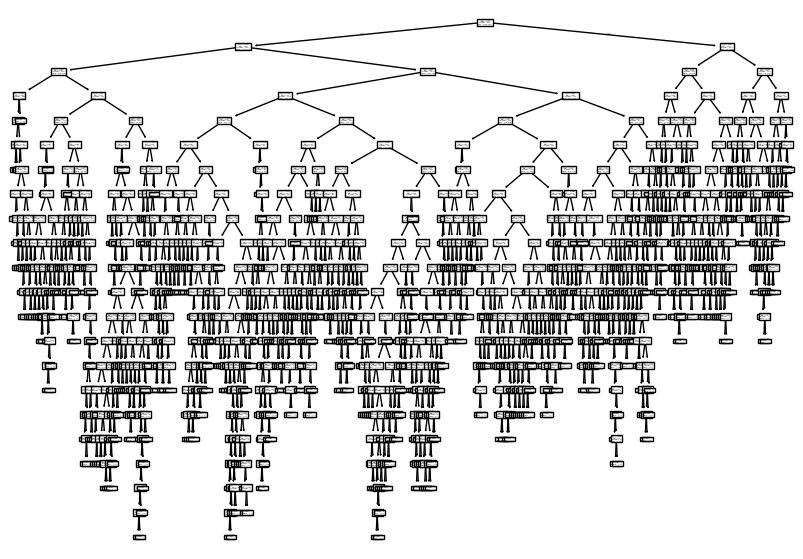

In [21]:
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

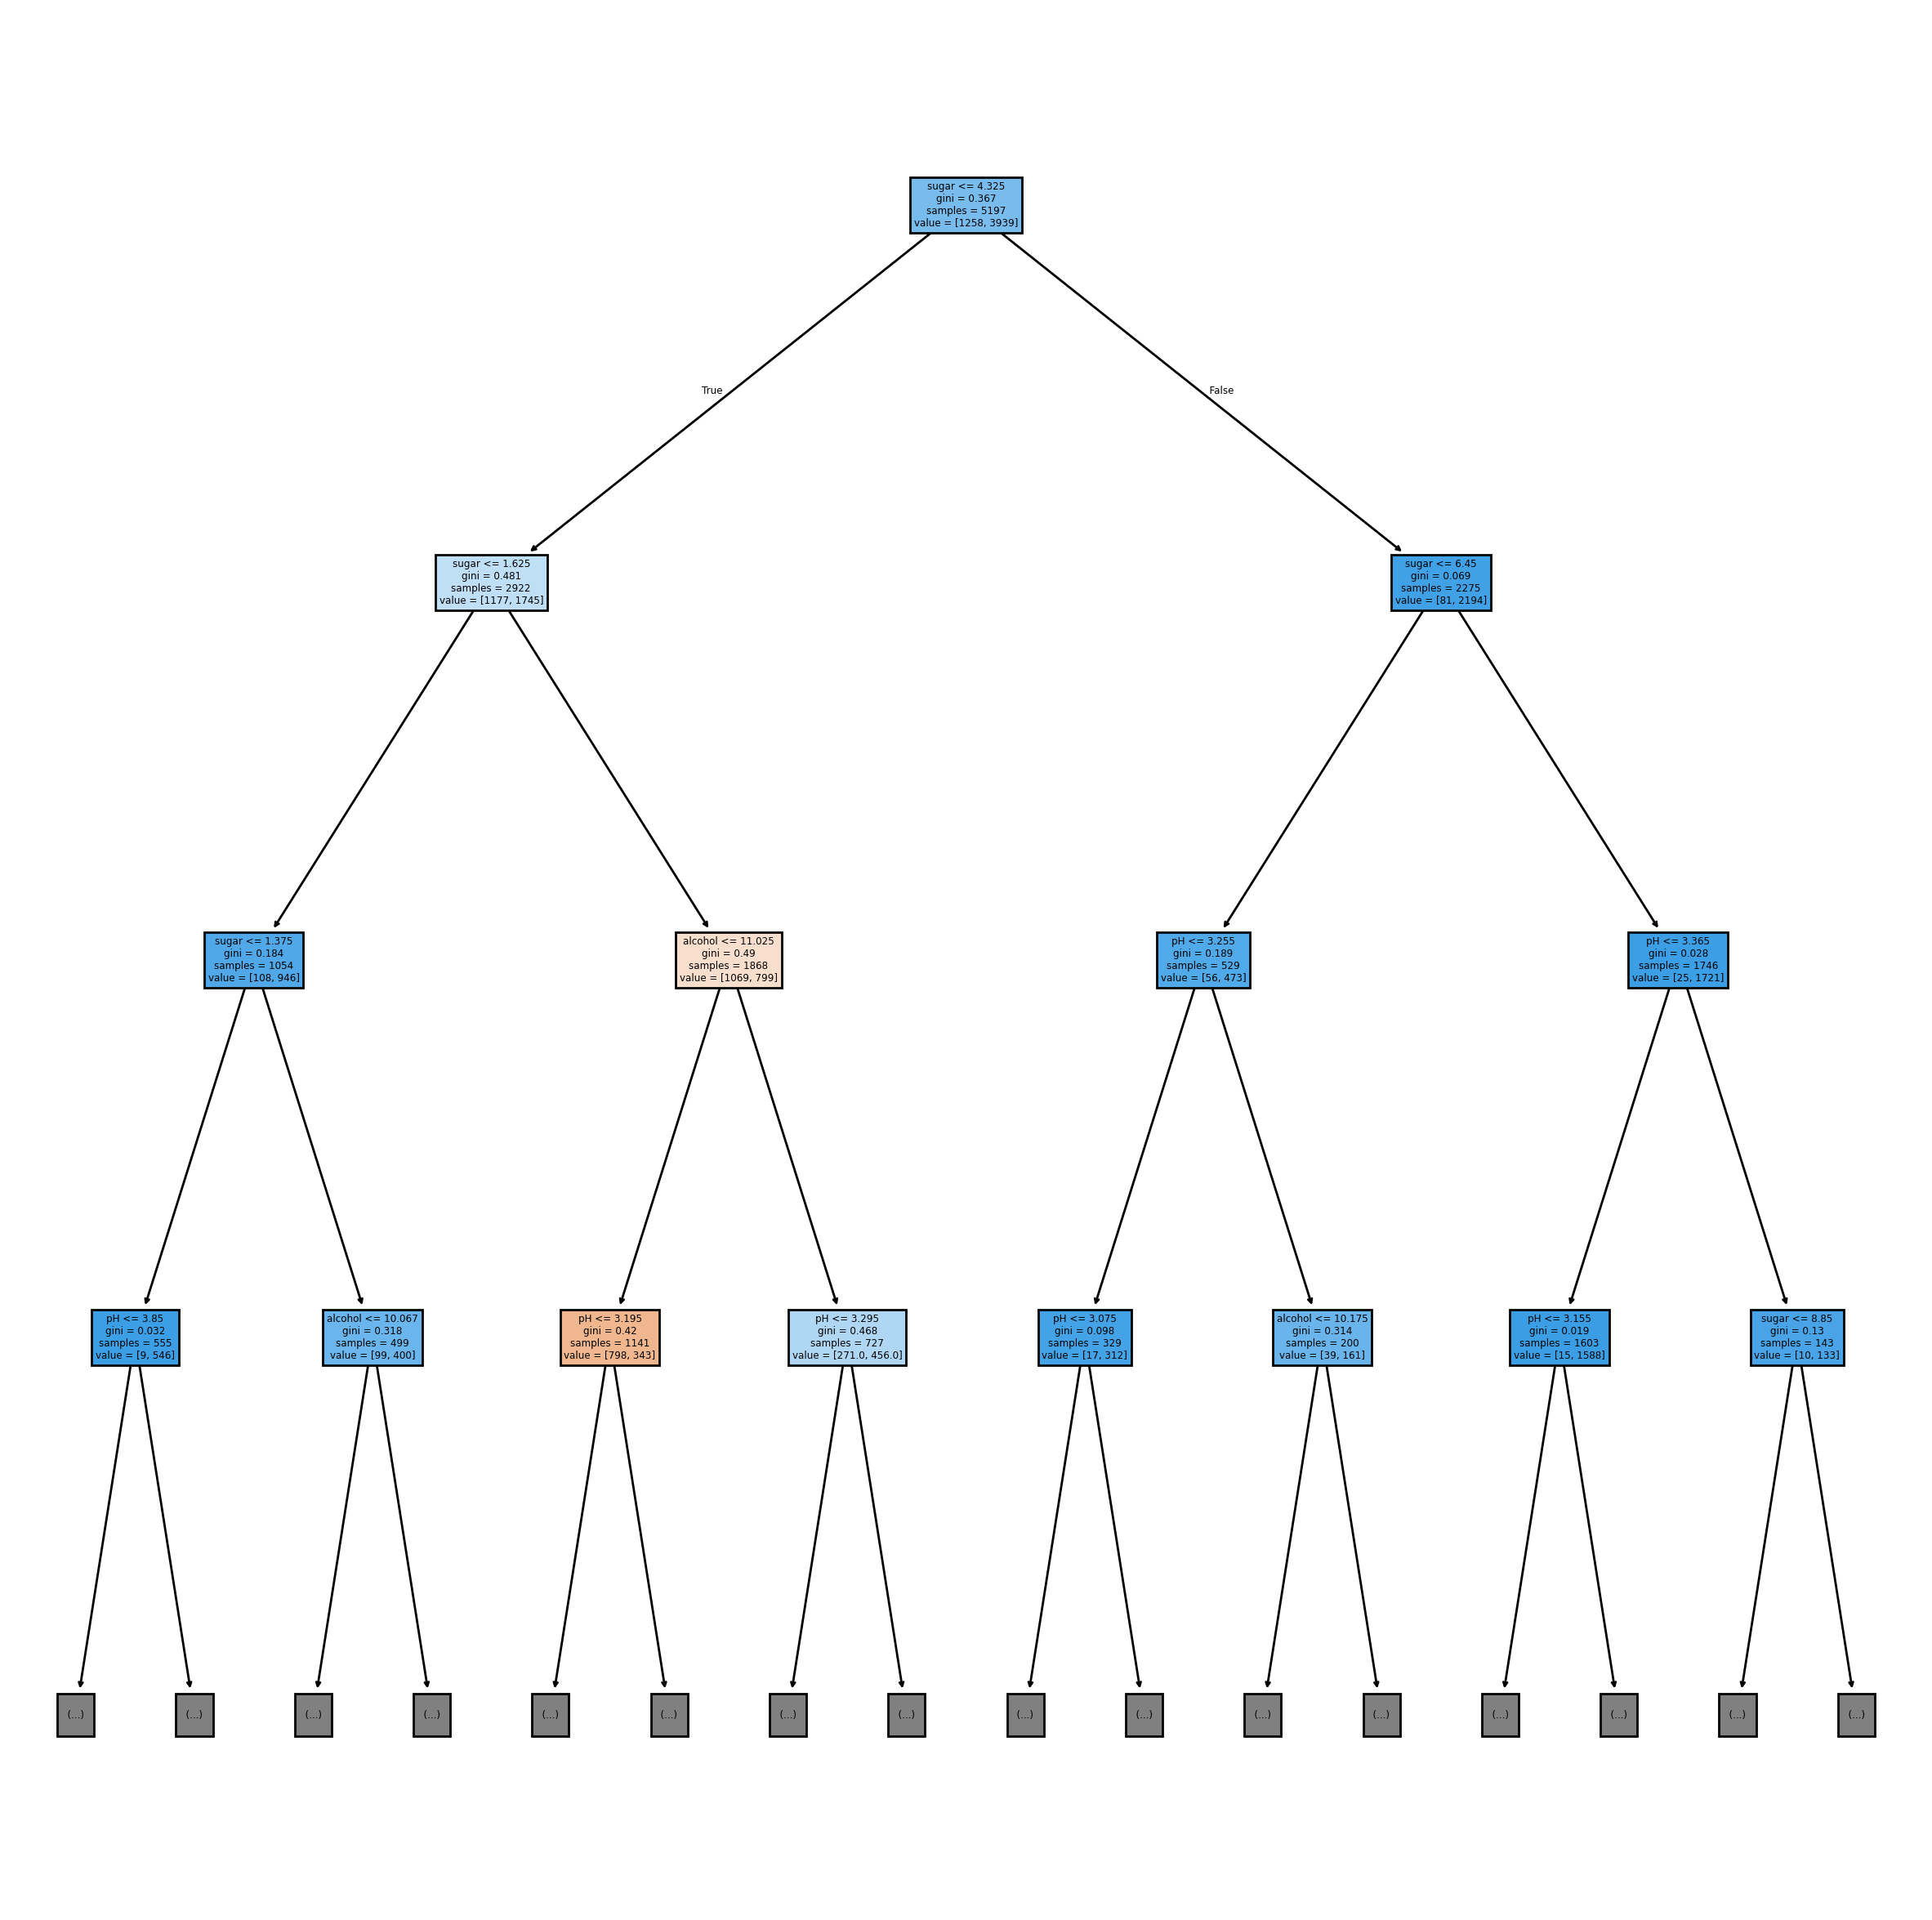

In [41]:
plt.figure(figsize=(15, 15), dpi=200)
plot_tree(dt, max_depth=3, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [ ]:
dt = DecisionTreeClassifier(random_state=42, max_depth=4) # max_depth의 기본값은 **None
dt.fit(X_train, y_train)
print(dt.score(X_train, y_train))
print(dt.score(X_test, y_test))


0.8572253223013276
0.8484615384615385


In [36]:
print(dt.feature_importances_) # 중요도. 설탕이 높음
print(np.sum(dt.feature_importances_)) # 중요도의 합은 1
print(dt.feature_importances_.argsort()) # 중요도 순서대로 인덱스 반환

[0.12745696 0.76704375 0.10549929]
1.0
[2 0 1]
